            State         Date Frequency  Unemployment_Rate  Employed  \
0  Andhra Pradesh   31-01-2020         M               5.48  16635535   
1  Andhra Pradesh   29-02-2020         M               5.83  16545652   
2  Andhra Pradesh   31-03-2020         M               5.79  15881197   
3  Andhra Pradesh   30-04-2020         M              20.51  11336911   
4  Andhra Pradesh   31-05-2020         M              17.43  12988845   

   Labour_Participation_Rate Region  Longitude  Latitude  
0                      41.02  South    15.9129     79.74  
1                      40.90  South    15.9129     79.74  
2                      39.18  South    15.9129     79.74  
3                      33.10  South    15.9129     79.74  
4                      36.46  South    15.9129     79.74  
<class 'pandas.DataFrame'>
RangeIndex: 267 entries, 0 to 266
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0

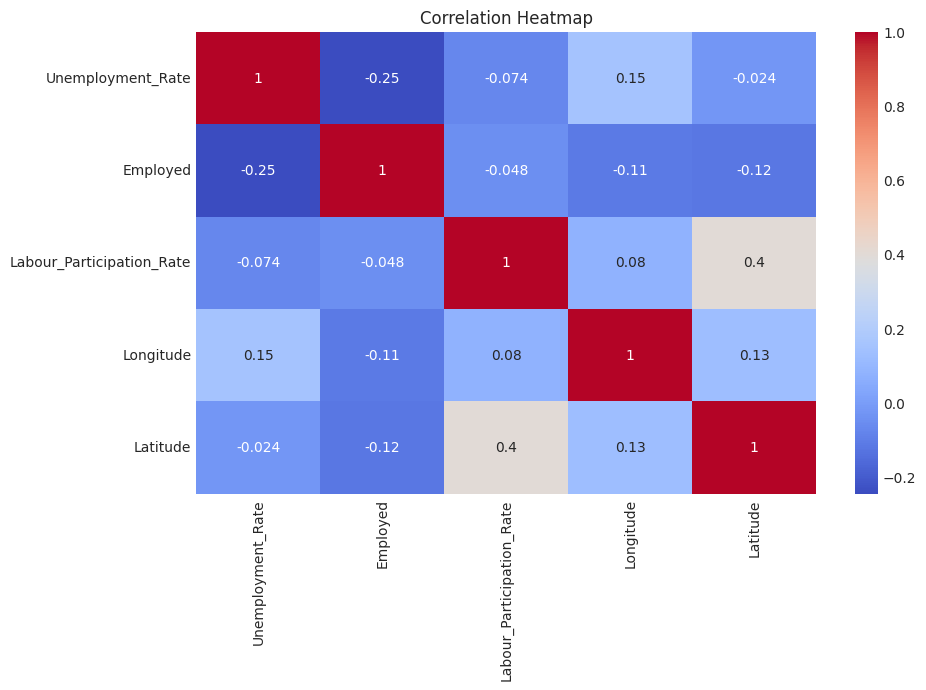

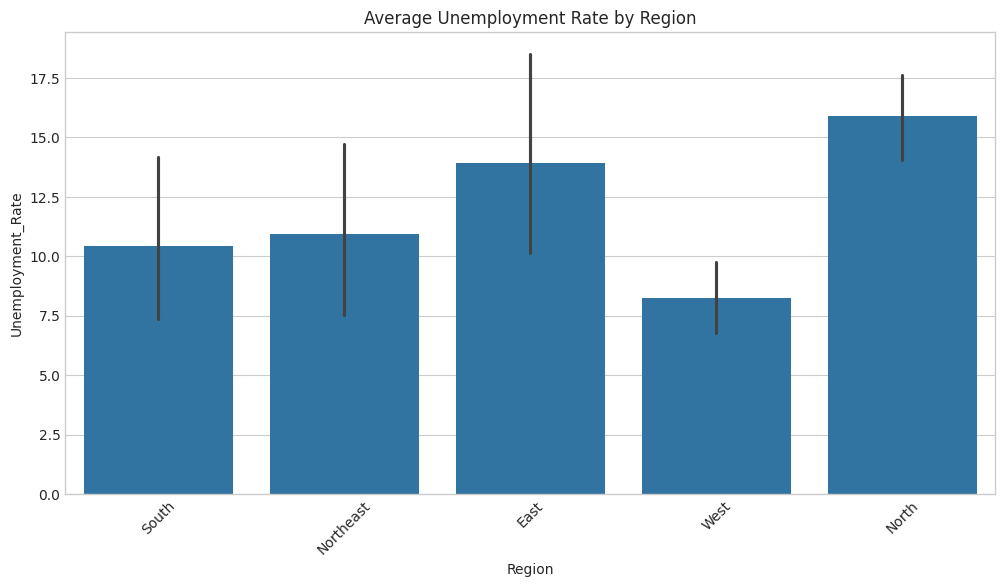

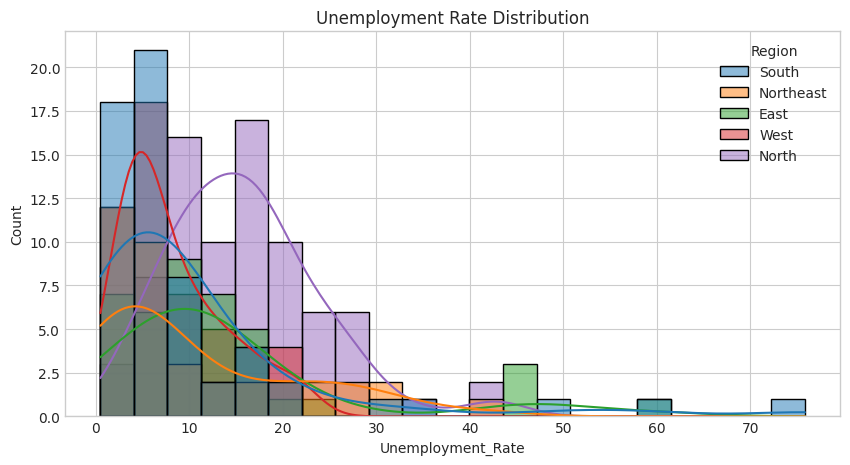

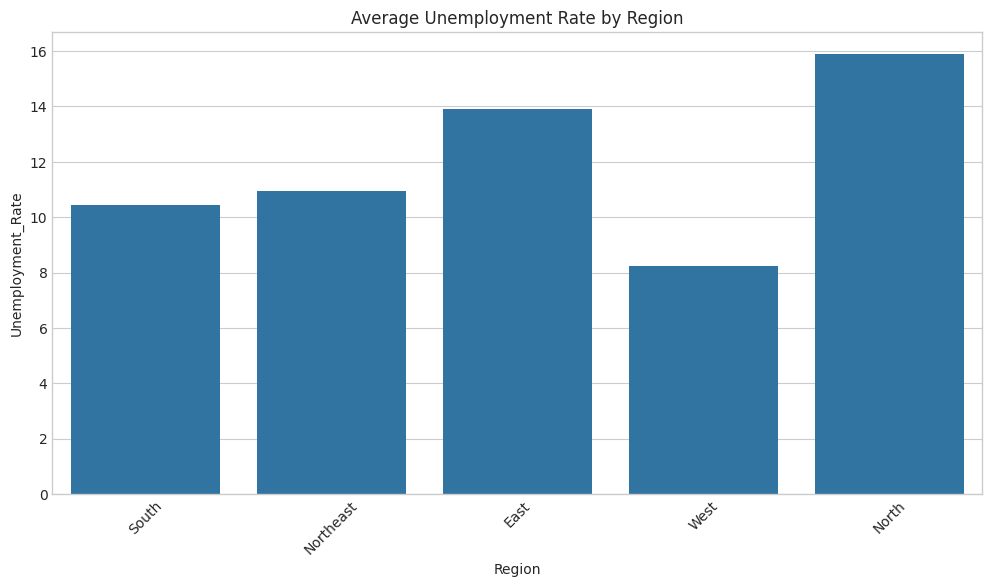

R2 Score: 0.00025789429934719443
MSE: 94.05076273022384


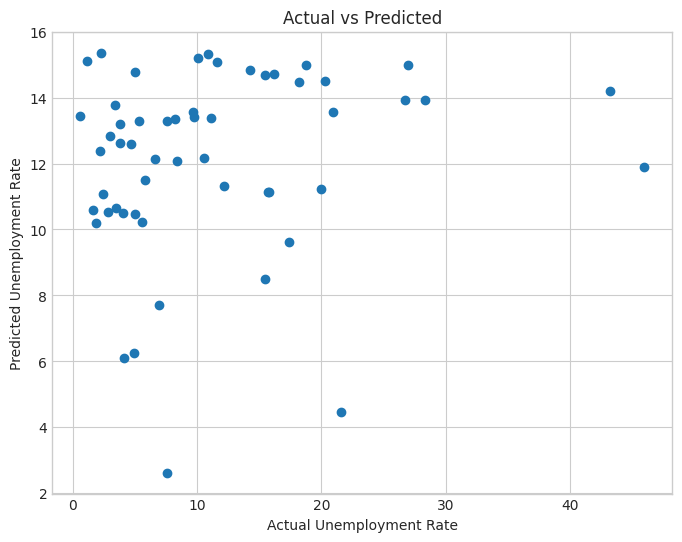

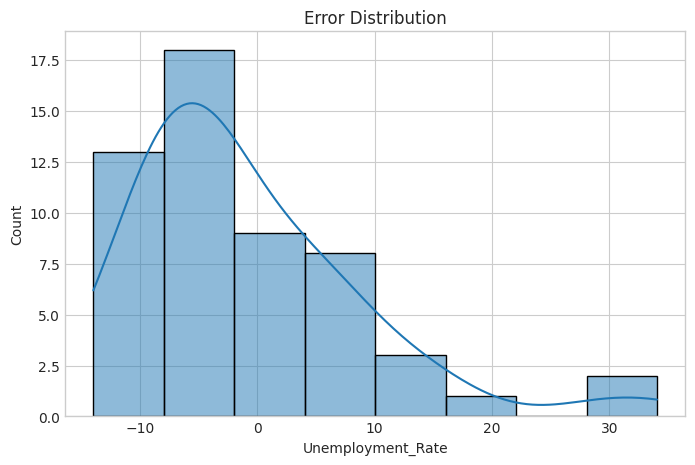

In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

plt.style.use("seaborn-v0_8-whitegrid")


data = pd.read_csv("https://raw.githubusercontent.com/amankharwal/Website-data/master/unemployment.csv")



data.columns = [
    "State", "Date", "Frequency",
    "Unemployment_Rate", "Employed",
    "Labour_Participation_Rate",
    "Region", "Longitude", "Latitude"
]



print(data.head())
print(data.info())
print(data.describe())
print(data.isnull().sum())


plt.figure(figsize=(10,6))
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()



plt.figure(figsize=(12,6))
sns.barplot(data=data, x="Region", y="Unemployment_Rate", estimator=np.mean)
plt.title("Average Unemployment Rate by Region")
plt.xticks(rotation=45)
plt.show()



plt.figure(figsize=(10,5))
sns.histplot(data=data, x="Unemployment_Rate", hue="Region", kde=True)
plt.title("Unemployment Rate Distribution")
plt.show()



plt.figure(figsize=(12,6))
sns.barplot(data=data, x="Region", y="Unemployment_Rate", estimator=np.mean, errorbar=None)
plt.title("Average Unemployment Rate by Region")
plt.xticks(rotation=45)
plt.show()


fig = px.sunburst(
    data,
    path=["Region", "State"],
    values="Unemployment_Rate",
    title="Unemployment Rate in India"
)
fig.show()



from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score



X = data[["Employed", "Labour_Participation_Rate", "Longitude", "Latitude"]]
y = data["Unemployment_Rate"]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)



model = LinearRegression()
model.fit(X_train, y_train)


y_pred = model.predict(X_test)



print("R2 Score:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))



plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Unemployment Rate")
plt.ylabel("Predicted Unemployment Rate")
plt.title("Actual vs Predicted")
plt.show()



residuals = y_test - y_pred

plt.figure(figsize=(8,5))
sns.histplot(residuals, kde=True)
plt.title("Error Distribution")
plt.show()
